In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [22]:
df=pd.read_csv("C:\\Users\\diwak\\Downloads\\Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [24]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


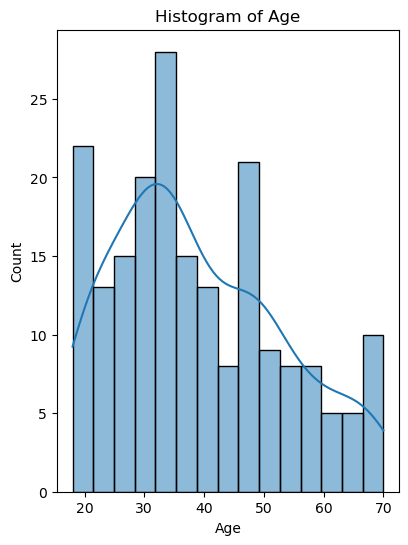

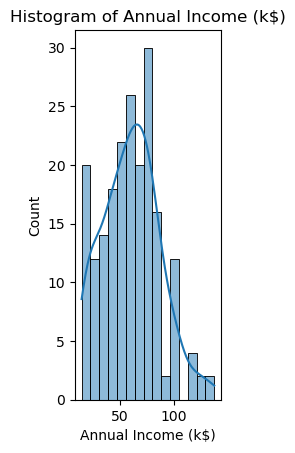

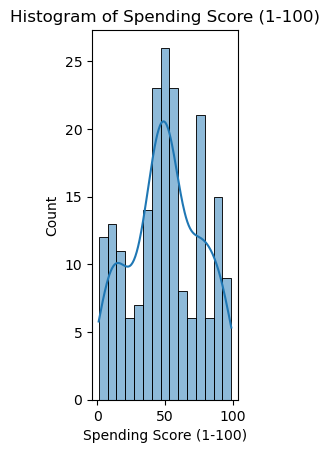

In [25]:
plt.figure(1, figsize=(15, 6))
i=1
for x in ["Age", "Annual Income (k$)", "Spending Score (1-100)"]:
    plt.subplot(1, 3, i)
    sns.histplot(df[x], bins=15, kde=True)
    plt.title("Histogram of {}".format(x))
    i+=1
    
    plt.show()

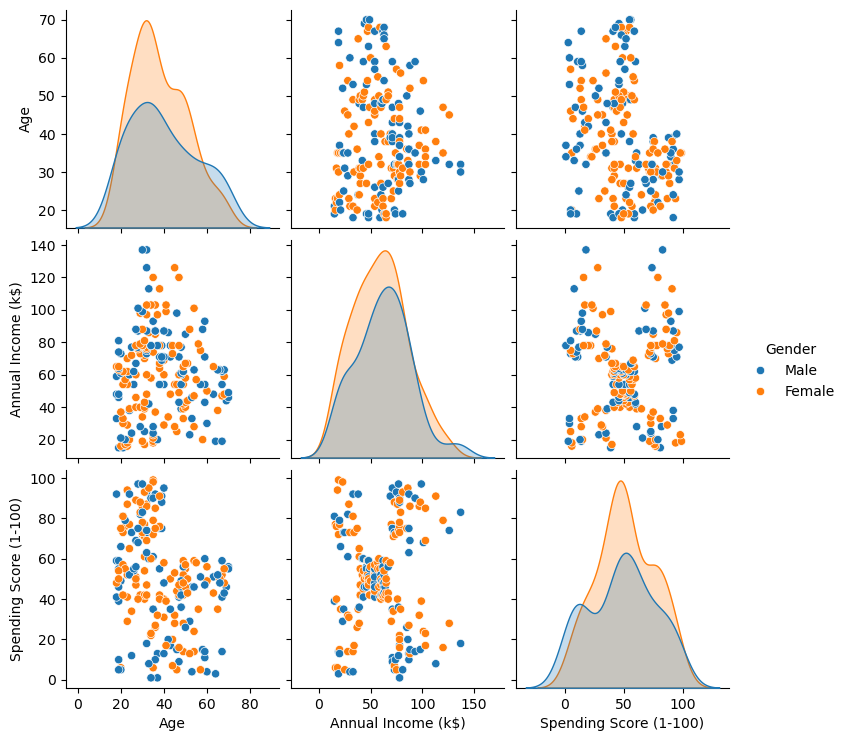

In [26]:
sns.pairplot(df, vars=["Age", "Annual Income (k$)", "Spending Score (1-100)"], hue="Gender")

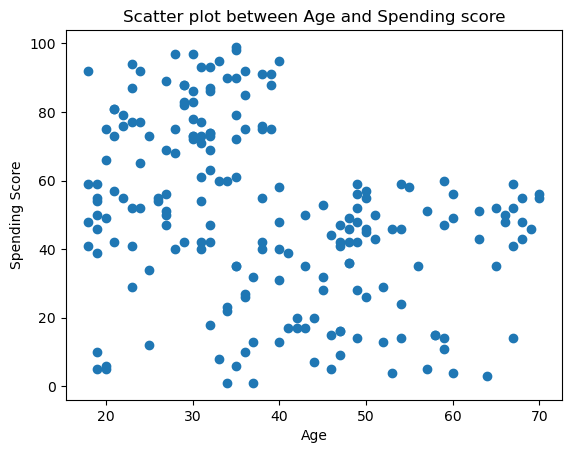

In [27]:
plt.scatter(df["Age"], df["Spending Score (1-100)"])
plt.title("Scatter plot between Age and Spending score")
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.show()

In [28]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [29]:
X=df.drop(columns=["CustomerID","Annual Income (k$)","Gender"],axis=1)
s=StandardScaler()
scaled_X=s.fit_transform(X)


k_range=range(2,15)
inertia=[]
sil=[]


for i in k_range:
    kmeans=KMeans(n_clusters=i,init="k-means++",n_init=10,max_iter=300,tol=0.0001,random_state=111,algorithm="lloyd")
    labels=kmeans.fit(scaled_X)
    inertia.append(kmeans.inertia_)
    sil.append(silhouette_score(scaled_X,kmeans.labels_))

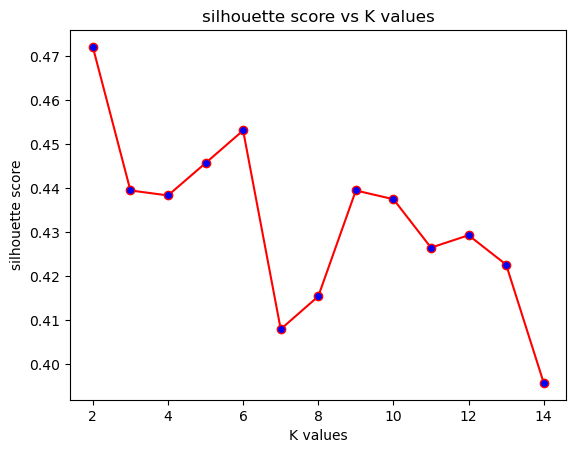

In [30]:
plt.title("silhouette score vs K values")
plt.plot(k_range,sil,marker="o",color="red",markerfacecolor="blue")
plt.xlabel("K values")
plt.ylabel("silhouette score")
plt.show()

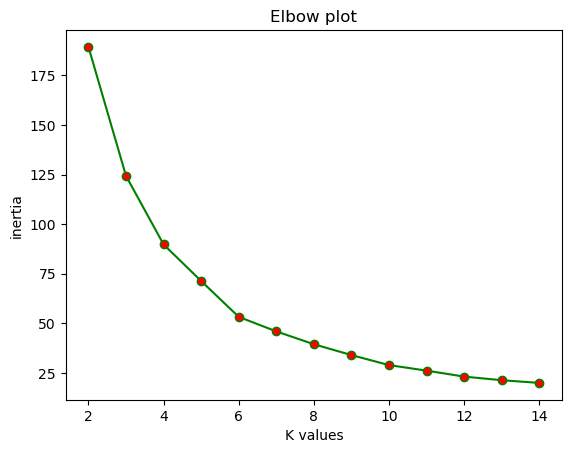

In [31]:
plt.title("Elbow plot")
plt.plot(k_range,inertia,marker="o",color="green",markerfacecolor="red")
plt.xlabel("K values")
plt.ylabel("inertia")
plt.show()

In [32]:
km=KMeans(n_clusters=5,init="k-means++",n_init=10,max_iter=300,tol=0.0001,random_state=111,algorithm="lloyd")
km.fit(scaled_X)
labels=km.labels_
centroids=km.cluster_centers_

In [33]:
arr_X=X.values

h=0.02
x_min, x_max = arr_X[:, 0].min() - 1, arr_X[:, 0].max() + 1
y_min, y_max = arr_X[:, 1].min() - 1, arr_X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = km.predict(np.c_[xx.ravel(), yy.ravel()])

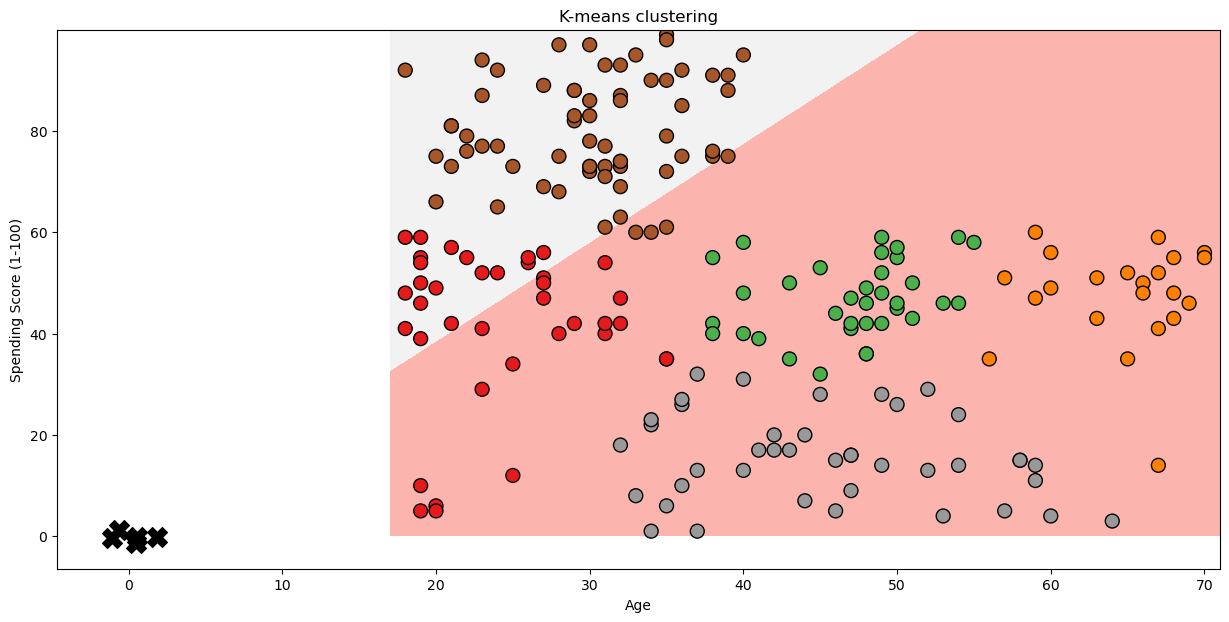

In [49]:
plt.figure(1,figsize=(15,7))
plt.clf()
Z = Z.reshape(xx.shape)
plt.imshow(Z, interpolation='nearest',
           extent=(xx.min(), xx.max(), yy.min(), yy.max()),
           cmap=plt.cm.Pastel1,
           aspect='auto', origin='lower')
plt.scatter(arr_X[:, 0], arr_X[:, 1], c=labels, edgecolor='k', s=100, cmap=plt.cm.Set1)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, c='black')
plt.title("K-means clustering")
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.show()

In [53]:
km = KMeans(n_clusters=i,init="k-means++", n_init=10,max_iter = 30,tol = 0.001,random_state=111,algorithm="lloyd")
km.fit(scaled_X)
labels = km.labels_
centroids = km.cluster_centers_

In [55]:
from sklearn.preprocessing import StandardScaler
import numpy as np
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)
arr_X = scaled_X
h = 0.02
x_min, x_max = arr_X[:, 0].min() - 1, arr_X[:, 0].max() + 1
y_min, y_max = arr_X[:, 1].min() - 1, arr_X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = km.predict(np.c_[xx.ravel(), yy.ravel()])

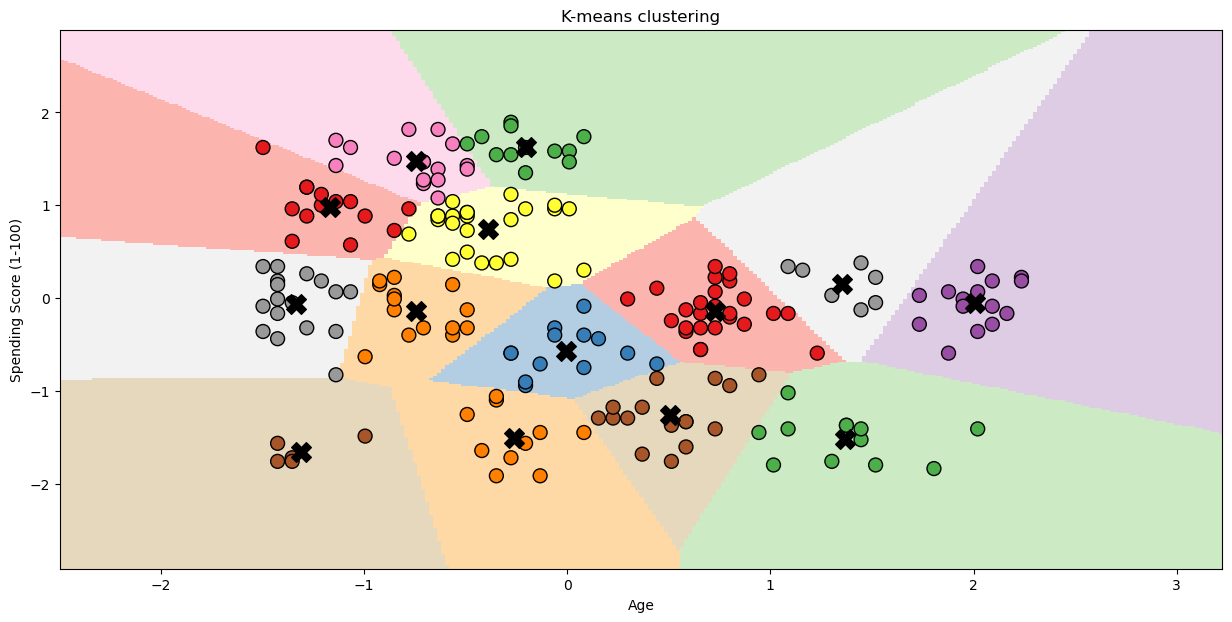

In [57]:
plt.figure(1,figsize=(15,7))
plt.clf()
Z = Z.reshape(xx.shape)
plt.imshow(Z, interpolation='nearest',
           extent=(xx.min(), xx.max(), yy.min(), yy.max()),
           cmap=plt.cm.Pastel1,
           aspect='auto', origin='lower')
plt.scatter(arr_X[:, 0], arr_X[:, 1], c=labels, edgecolor='k', s=100, cmap=plt.cm.Set1)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, c='black')
plt.title("K-means clustering")
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.show()